In [1]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import regularizers

print(tf.__version__)


2.20.0


In [31]:
# Usando matplotlib diretamente em vez de tensorflow-docs
import matplotlib.pyplot as plt
import pandas as pd

# Classe helper simples para substituir tensorflow_docs.plots.HistoryPlotter
class HistoryPlotter:
    def __init__(self, metric='loss', smoothing_std=0):
        self.metric = metric
        self.smoothing_std = smoothing_std
    
    def plot(self, histories):
        for name, history in histories.items():
            if self.metric in history.history:
                train_values = history.history[self.metric]
                val_metric = f'val_{self.metric}'
                if val_metric in history.history:
                    val_values = history.history[val_metric]
                    plt.plot(train_values, label=f'{name} Train')
                    plt.plot(val_values, '--', label=f'{name} Val')
                else:
                    plt.plot(train_values, label=name)

# Criar um objeto tfdocs.plots mock para compatibilidade
class MockTFDocs:
    class plots:
        HistoryPlotter = HistoryPlotter

tfdocs = MockTFDocs()


In [4]:
from  IPython import display
from matplotlib import pyplot as plt

import numpy as np

import pathlib
import shutil
import tempfile

logdir = pathlib.Path(tempfile.mkdtemp())/"tensorboard_logs"
shutil.rmtree(logdir, ignore_errors=True)



In [5]:
import tensorflow as tf

gz = tf.keras.utils.get_file(
    'HIGGS.csv.gz',
    'https://archive.ics.uci.edu/ml/machine-learning-databases/00280/HIGGS.csv.gz'
)

print("Arquivo salvo em:", gz)

2444615680/Unknown 922s 0us/stepArquivo salvo em: C:\Users\pedro\.keras\datasets\HIGGS.csv.gz
Arquivo salvo em: C:\Users\pedro\.keras\datasets\HIGGS.csv.gz


tf.Tensor(
[ 0.8692932  -0.6350818   0.22569026  0.32747006 -0.6899932   0.75420225
 -0.24857314 -1.0920639   0.          1.3749921  -0.6536742   0.9303491
  1.1074361   1.1389043  -1.5781983  -1.0469854   0.          0.65792954
 -0.01045457 -0.04576717  3.1019614   1.35376     0.9795631   0.97807616
  0.92000484  0.72165745  0.98875093  0.87667835], shape=(28,), dtype=float32)


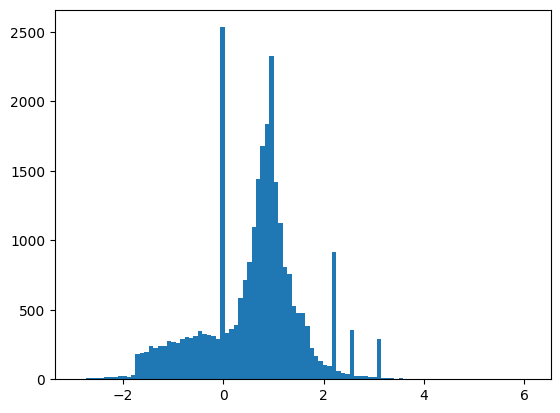

In [11]:
# Configuração do dataset HIGGS
FEATURES = 28
ds = tf.data.experimental.CsvDataset(gz,[float(),]*(FEATURES+1), compression_type="GZIP")

def pack_row(*row):
    label = row[0] 
    features = tf.stack(row[1:],1)
    return features, label

packed_ds = ds.batch(10000).map(pack_row).unbatch()

# Visualizar algumas amostras
for features,label in packed_ds.batch(1000).take(1):
    print(features[0])
    plt.hist(features.numpy().flatten(), bins=101)

Overfitting e Underfitting

1. **Dataset HIGGS** - Dados de física de partículas
2. **Dataset Fashion-MNIST** - Imagens de roupas
3. **Dataset Iris** - Dados clássicos de flores


In [7]:
# Preparação dos datasets para comparação
N_VALIDATION = int(1e3)
N_TRAIN = int(1e4)
BUFFER_SIZE = int(1e4)
BATCH_SIZE = 500
STEPS_PER_EPOCH = N_TRAIN//BATCH_SIZE

# Dividir o dataset HIGGS
validate_ds = packed_ds.take(N_VALIDATION).cache()
train_ds = packed_ds.skip(N_VALIDATION).take(N_TRAIN).cache()

# Preparar os datasets
validate_ds = validate_ds.batch(BATCH_SIZE)
train_ds = train_ds.shuffle(BUFFER_SIZE).repeat().batch(BATCH_SIZE)

## Dataset 1: HIGGS - Demonstração de Overfitting

Vamos criar diferentes modelos com complexidades variadas para demonstrar underfitting, fitting adequado e overfitting.

In [12]:

# Modelo Pequeno (Underfitting provável)
def create_tiny_model():
    return tf.keras.Sequential([
        layers.Dense(16, activation='elu', input_shape=(FEATURES,)),
        layers.Dense(1, activation='sigmoid')
    ])

# Modelo Pequeno 
def create_small_model():
    return tf.keras.Sequential([
        layers.Dense(16, activation='elu', input_shape=(FEATURES,)),
        layers.Dense(16, activation='elu'),
        layers.Dense(1, activation='sigmoid')
    ])

# Modelo Médio
def create_medium_model():
    return tf.keras.Sequential([
        layers.Dense(64, activation='elu', input_shape=(FEATURES,)),
        layers.Dense(64, activation='elu'),
        layers.Dense(64, activation='elu'),
        layers.Dense(1, activation='sigmoid')
    ])

# Modelo Grande (Overfitting provável)
def create_large_model():
    return tf.keras.Sequential([
        layers.Dense(512, activation='elu', input_shape=(FEATURES,)),
        layers.Dense(512, activation='elu'),
        layers.Dense(512, activation='elu'),
        layers.Dense(512, activation='elu'),
        layers.Dense(1, activation='sigmoid')
    ])

In [13]:
# Configurar e treinar os modelos HIGGS
size_histories = {}

# Treinar todos os modelos
models = [
    ("Tiny", create_tiny_model()),
    ("Small", create_small_model()),
    ("Medium", create_medium_model()),
    ("Large", create_large_model())
]

for name, model in models:
    print(f"\nTreinando modelo {name}...")
    
    # Compilar modelo
    model.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])
    
    # Treinar
    size_histories[name] = model.fit(
        train_ds,
        epochs=20,
        steps_per_epoch=STEPS_PER_EPOCH,
        validation_data=validate_ds,
        verbose=0
    )


Treinando modelo Tiny...


C:\Users\pedro\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Treinando modelo Small...

Treinando modelo Medium...

Treinando modelo Medium...

Treinando modelo Large...

Treinando modelo Large...


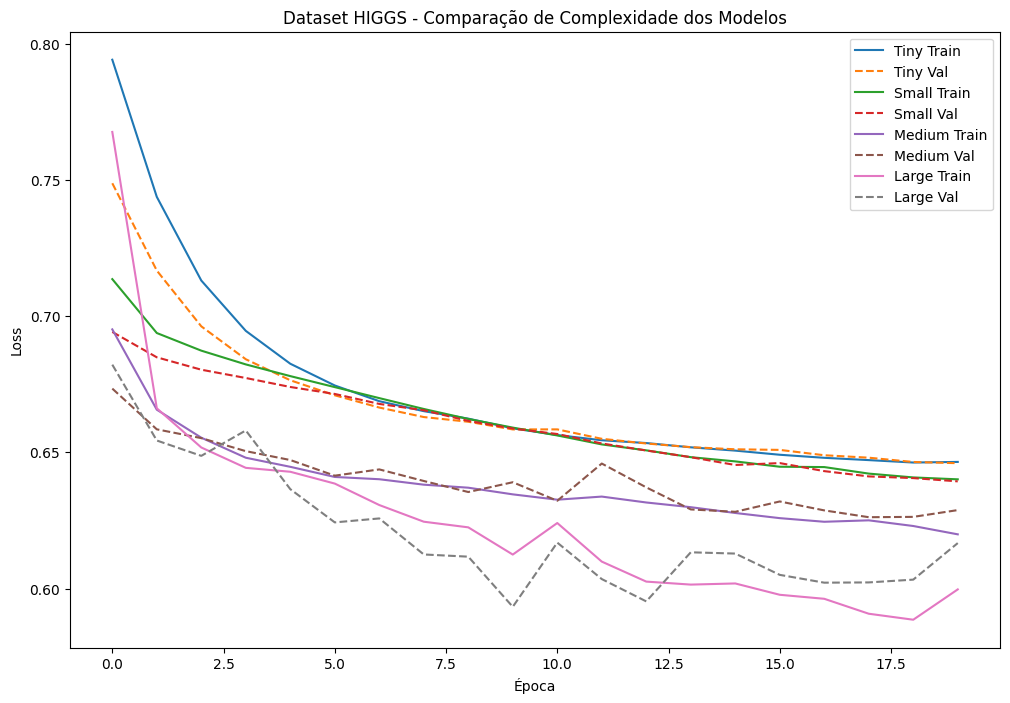

In [14]:
# Plotar resultados do treinamento HIGGS
plotter = tfdocs.plots.HistoryPlotter(metric = 'loss', smoothing_std=10)

plt.figure(figsize=(12, 8))
plotter.plot(size_histories)
plt.title('Dataset HIGGS - Comparação de Complexidade dos Modelos')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Estratégias de Regularização para HIGGS

aplicar técnicas de regularização para controlar o overfitting:
- Weight regularization(L1 e L2)
- Dropout
- Early stopping

In [15]:
# Modelos com diferentes técnicas de regularização para HIGGS

# Modelo com regularização L2
def create_l2_model():
    return tf.keras.Sequential([
        layers.Dense(512, activation='elu',
                    kernel_regularizer=regularizers.l2(0.001),
                    input_shape=(FEATURES,)),
        layers.Dense(512, activation='elu',
                    kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(512, activation='elu',
                    kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(512, activation='elu',
                    kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(1, activation='sigmoid')
    ])

# Modelo com Dropout
def create_dropout_model():
    return tf.keras.Sequential([
        layers.Dense(512, activation='elu', input_shape=(FEATURES,)),
        layers.Dropout(0.5),
        layers.Dense(512, activation='elu'),
        layers.Dropout(0.5),
        layers.Dense(512, activation='elu'),
        layers.Dropout(0.5),
        layers.Dense(512, activation='elu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

# Modelo combinado (L2 + Dropout)
def create_combined_model():
    return tf.keras.Sequential([
        layers.Dense(512, activation='elu',
                    kernel_regularizer=regularizers.l2(0.0001),
                    input_shape=(FEATURES,)),
        layers.Dropout(0.5),
        layers.Dense(512, activation='elu',
                    kernel_regularizer=regularizers.l2(0.0001)),
        layers.Dropout(0.5),
        layers.Dense(512, activation='elu',
                    kernel_regularizer=regularizers.l2(0.0001)),
        layers.Dropout(0.5),
        layers.Dense(512, activation='elu',
                    kernel_regularizer=regularizers.l2(0.0001)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

In [16]:
# Treinar modelos regularizados para HIGGS
regularization_histories = {}

regularization_models = [
    ("Large", create_large_model()),
    ("L2", create_l2_model()),
    ("Dropout", create_dropout_model()),
    ("Combined", create_combined_model())
]

for name, model in regularization_models:
    print(f"\nTreinando modelo {name} com regularização...")
    
    model.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])
    
    regularization_histories[name] = model.fit(
        train_ds,
        epochs=20,
        steps_per_epoch=STEPS_PER_EPOCH,
        validation_data=validate_ds,
        verbose=0
    )


Treinando modelo Large com regularização...

Treinando modelo L2 com regularização...

Treinando modelo L2 com regularização...

Treinando modelo Dropout com regularização...

Treinando modelo Dropout com regularização...

Treinando modelo Combined com regularização...

Treinando modelo Combined com regularização...


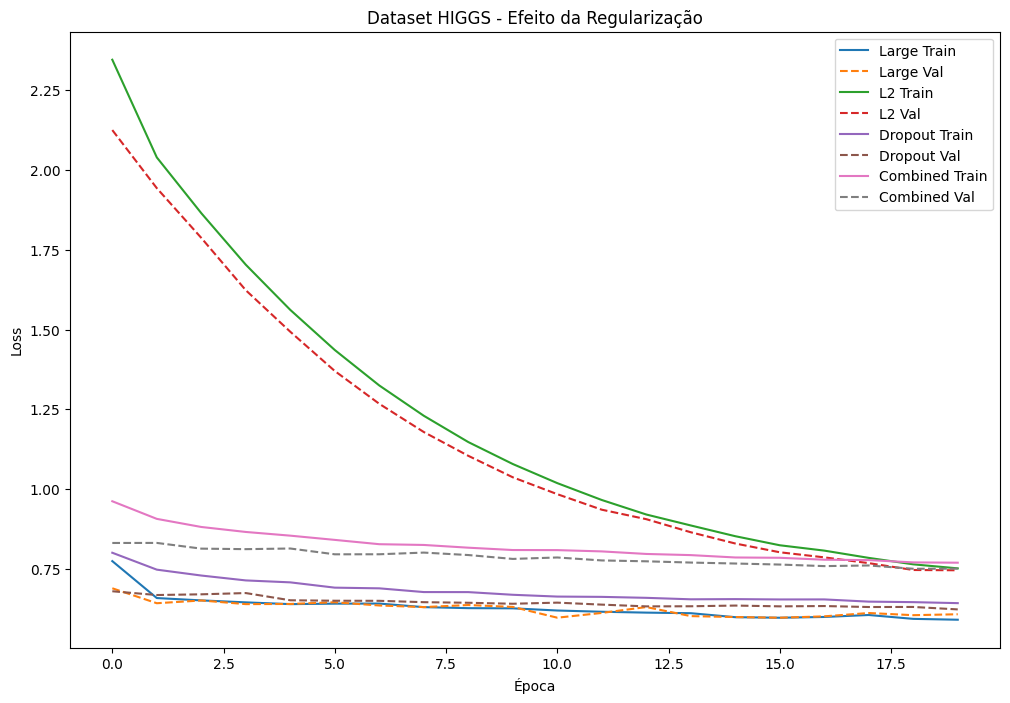

In [17]:
# Plotar resultados da regularização HIGGS
plotter = tfdocs.plots.HistoryPlotter(metric = 'loss', smoothing_std=10)

plt.figure(figsize=(12, 8))
plotter.plot(regularization_histories)
plt.title('Dataset HIGGS - Efeito da Regularização')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Dataset 2: Fashion-MNIST - Demonstração com Dados de Imagem

aplicar os mesmos conceitos ao dataset Fashion-MNIST para ver como overfitting e underfitting se comportam com dados de imagem.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Formato dos dados de treino: (60000, 784)
Formato dos labels de treino: (60000,)
Número de classes: 10
Formato dos dados de treino: (60000, 784)
Formato dos labels de treino: (60000,)
Número de classes: 10


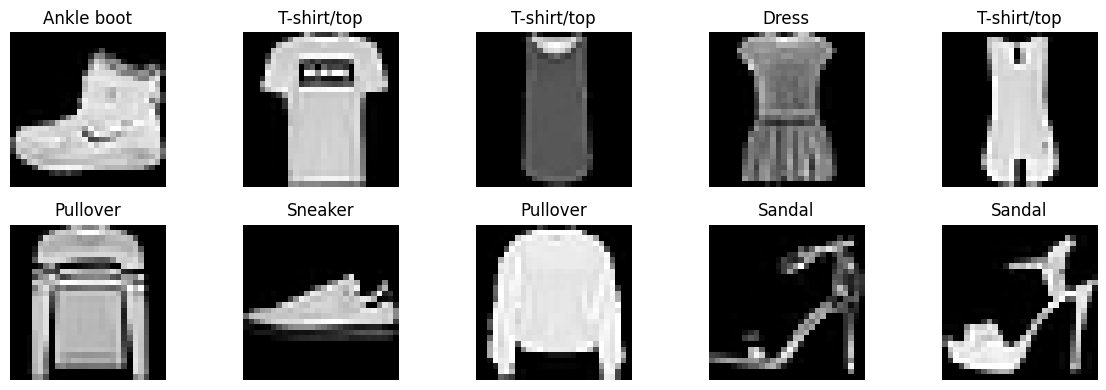

In [18]:
# Carregar e preparar o dataset Fashion-MNIST
(x_train_fashion, y_train_fashion), (x_test_fashion, y_test_fashion) = tf.keras.datasets.fashion_mnist.load_data()

# Normalizar os dados
x_train_fashion = x_train_fashion.astype('float32') / 255.0
x_test_fashion = x_test_fashion.astype('float32') / 255.0

# Flatten para usar com Dense layers
x_train_fashion_flat = x_train_fashion.reshape(x_train_fashion.shape[0], -1)
x_test_fashion_flat = x_test_fashion.reshape(x_test_fashion.shape[0], -1)

print(f"Formato dos dados de treino: {x_train_fashion_flat.shape}")
print(f"Formato dos labels de treino: {y_train_fashion.shape}")
print(f"Número de classes: {len(np.unique(y_train_fashion))}")

# Visualizar algumas imagens
plt.figure(figsize=(12, 4))
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_fashion[i], cmap='gray')
    plt.title(f'{class_names[y_train_fashion[i]]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [19]:
# Modelos para Fashion-MNIST com diferentes complexidades

def create_fashion_tiny_model():
    return tf.keras.Sequential([
        layers.Dense(32, activation='relu', input_shape=(784,)),
        layers.Dense(10, activation='softmax')
    ])

def create_fashion_small_model():
    return tf.keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(784,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

def create_fashion_medium_model():
    return tf.keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

def create_fashion_large_model():
    return tf.keras.Sequential([
        layers.Dense(512, activation='relu', input_shape=(784,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

In [20]:
# Treinar modelos Fashion-MNIST
fashion_histories = {}

fashion_models = [
    ("Tiny", create_fashion_tiny_model()),
    ("Small", create_fashion_small_model()),
    ("Medium", create_fashion_medium_model()),
    ("Large", create_fashion_large_model())
]

for name, model in fashion_models:
    print(f"\nTreinando modelo Fashion-MNIST {name}...")
    
    model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    
    fashion_histories[name] = model.fit(
        x_train_fashion_flat, y_train_fashion,
        epochs=20,
        batch_size=128,
        validation_data=(x_test_fashion_flat, y_test_fashion),
        verbose=0
    )


Treinando modelo Fashion-MNIST Tiny...

Treinando modelo Fashion-MNIST Small...

Treinando modelo Fashion-MNIST Small...

Treinando modelo Fashion-MNIST Medium...

Treinando modelo Fashion-MNIST Medium...

Treinando modelo Fashion-MNIST Large...

Treinando modelo Fashion-MNIST Large...


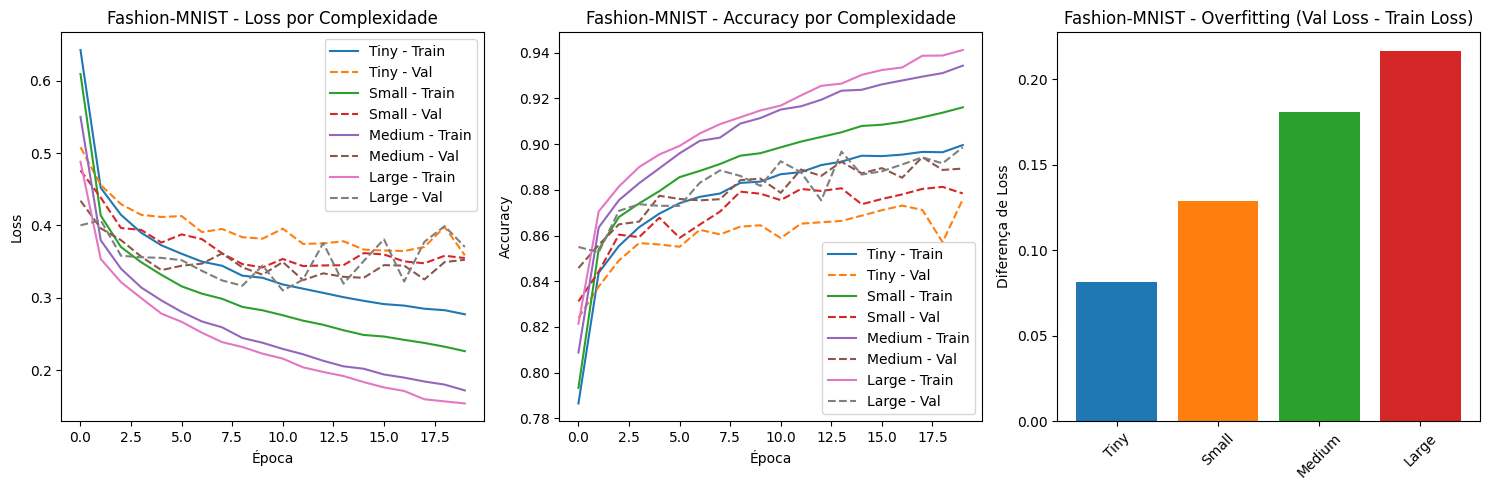

In [21]:
# Plotar resultados Fashion-MNIST
plt.figure(figsize=(15, 5))

# Loss
plt.subplot(1, 3, 1)
for name, history in fashion_histories.items():
    plt.plot(history.history['loss'], label=f'{name} - Train')
    plt.plot(history.history['val_loss'], '--', label=f'{name} - Val')
plt.title('Fashion-MNIST - Loss por Complexidade')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 3, 2)
for name, history in fashion_histories.items():
    plt.plot(history.history['accuracy'], label=f'{name} - Train')
    plt.plot(history.history['val_accuracy'], '--', label=f'{name} - Val')
plt.title('Fashion-MNIST - Accuracy por Complexidade')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Overfitting analysis
plt.subplot(1, 3, 3)
for name, history in fashion_histories.items():
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]
    overfitting = val_loss - train_loss
    plt.bar(name, overfitting)
plt.title('Fashion-MNIST - Overfitting (Val Loss - Train Loss)')
plt.ylabel('Diferença de Loss')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
# Regularização para Fashion-MNIST

def create_fashion_regularized_model():
    return tf.keras.Sequential([
        layers.Dense(512, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001),
                    input_shape=(784,)),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

# Comparar modelo grande vs regularizado
print("Treinando modelo Fashion-MNIST regularizado...")

model_reg = create_fashion_regularized_model()
model_reg.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history_reg = model_reg.fit(
    x_train_fashion_flat, y_train_fashion,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_fashion_flat, y_test_fashion),
    verbose=0
)

# Comparar com modelo large
fashion_reg_comparison = {
    'Large': fashion_histories['Large'],
    'Regularized': history_reg
}

Treinando modelo Fashion-MNIST regularizado...


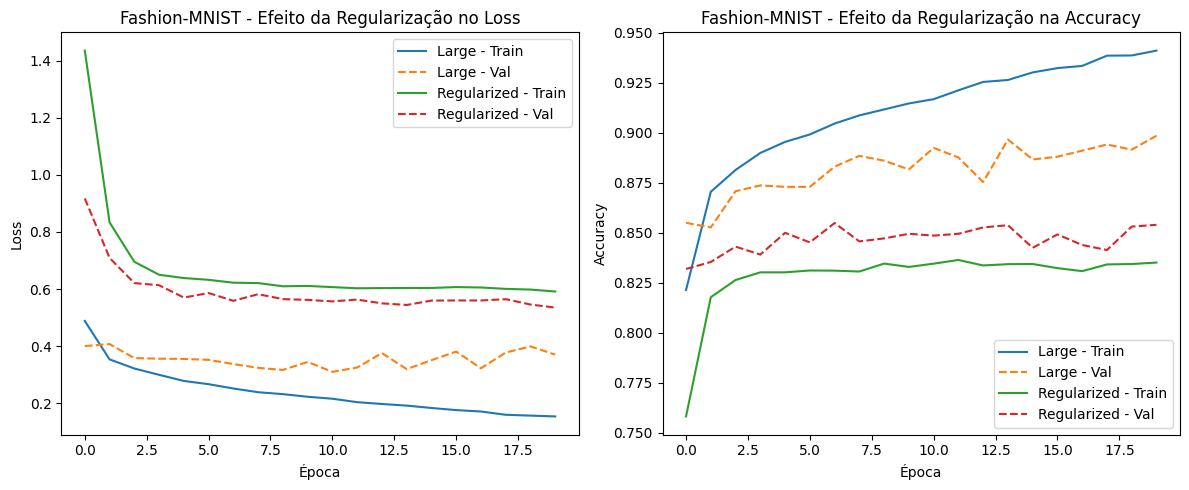

In [23]:
# Plotar comparação de regularização Fashion-MNIST
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for name, history in fashion_reg_comparison.items():
    plt.plot(history.history['loss'], label=f'{name} - Train')
    plt.plot(history.history['val_loss'], '--', label=f'{name} - Val')
plt.title('Fashion-MNIST - Efeito da Regularização no Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
for name, history in fashion_reg_comparison.items():
    plt.plot(history.history['accuracy'], label=f'{name} - Train')
    plt.plot(history.history['val_accuracy'], '--', label=f'{name} - Val')
plt.title('Fashion-MNIST - Efeito da Regularização na Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Dataset 3: Iris - Demonstração com Dataset Clássico

Por fim, aplicar os conceitos ao dataset Iris, um dataset pequeno e clássico de machine learning para demonstrar como o tamanho do dataset afeta overfitting e underfitting.

Formato dos dados de treino: (120, 4)
Formato dos dados de teste: (30, 4)
Número de features: 4
Número de classes: 3
Classes: ['setosa' 'versicolor' 'virginica']


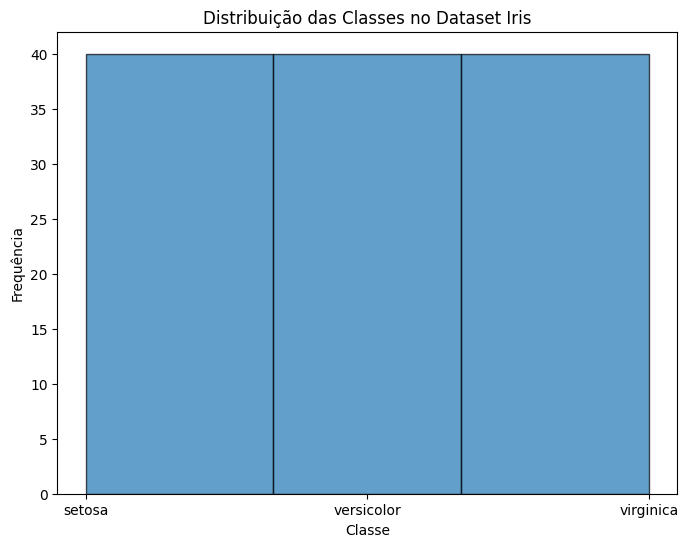

In [24]:
# Carregar e preparar o dataset Iris
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Carregar dados
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Dividir em treino e teste
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

# Normalizar
scaler = StandardScaler()
X_train_iris = scaler.fit_transform(X_train_iris)
X_test_iris = scaler.transform(X_test_iris)

print(f"Formato dos dados de treino: {X_train_iris.shape}")
print(f"Formato dos dados de teste: {X_test_iris.shape}")
print(f"Número de features: {X_iris.shape[1]}")
print(f"Número de classes: {len(np.unique(y_iris))}")
print(f"Classes: {iris.target_names}")

# Visualizar distribuição das classes
plt.figure(figsize=(8, 6))
plt.hist(y_train_iris, bins=3, alpha=0.7, edgecolor='black')
plt.title('Distribuição das Classes no Dataset Iris')
plt.xlabel('Classe')
plt.ylabel('Frequência')
plt.xticks([0, 1, 2], iris.target_names)
plt.show()

In [25]:
# Modelos para dataset Iris com diferentes complexidades

def create_iris_tiny_model():
    return tf.keras.Sequential([
        layers.Dense(3, activation='relu', input_shape=(4,)),
        layers.Dense(3, activation='softmax')
    ])

def create_iris_small_model():
    return tf.keras.Sequential([
        layers.Dense(8, activation='relu', input_shape=(4,)),
        layers.Dense(3, activation='softmax')
    ])

def create_iris_medium_model():
    return tf.keras.Sequential([
        layers.Dense(16, activation='relu', input_shape=(4,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

def create_iris_large_model():
    return tf.keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(4,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

# Modelo ainda maior para forçar overfitting em dataset pequeno
def create_iris_huge_model():
    return tf.keras.Sequential([
        layers.Dense(512, activation='relu', input_shape=(4,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

In [26]:
# Treinar modelos Iris
iris_histories = {}

iris_models = [
    ("Tiny", create_iris_tiny_model()),
    ("Small", create_iris_small_model()),
    ("Medium", create_iris_medium_model()),
    ("Large", create_iris_large_model()),
    ("Huge", create_iris_huge_model())
]

for name, model in iris_models:
    print(f"\nTreinando modelo Iris {name}...")
    
    model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    
    iris_histories[name] = model.fit(
        X_train_iris, y_train_iris,
        epochs=100,  # Mais épocas para dataset pequeno
        batch_size=8,  # Batch pequeno para dataset pequeno
        validation_data=(X_test_iris, y_test_iris),
        verbose=0
    )

C:\Users\pedro\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Treinando modelo Iris Tiny...

Treinando modelo Iris Small...

Treinando modelo Iris Small...

Treinando modelo Iris Medium...

Treinando modelo Iris Medium...

Treinando modelo Iris Large...

Treinando modelo Iris Large...

Treinando modelo Iris Huge...

Treinando modelo Iris Huge...


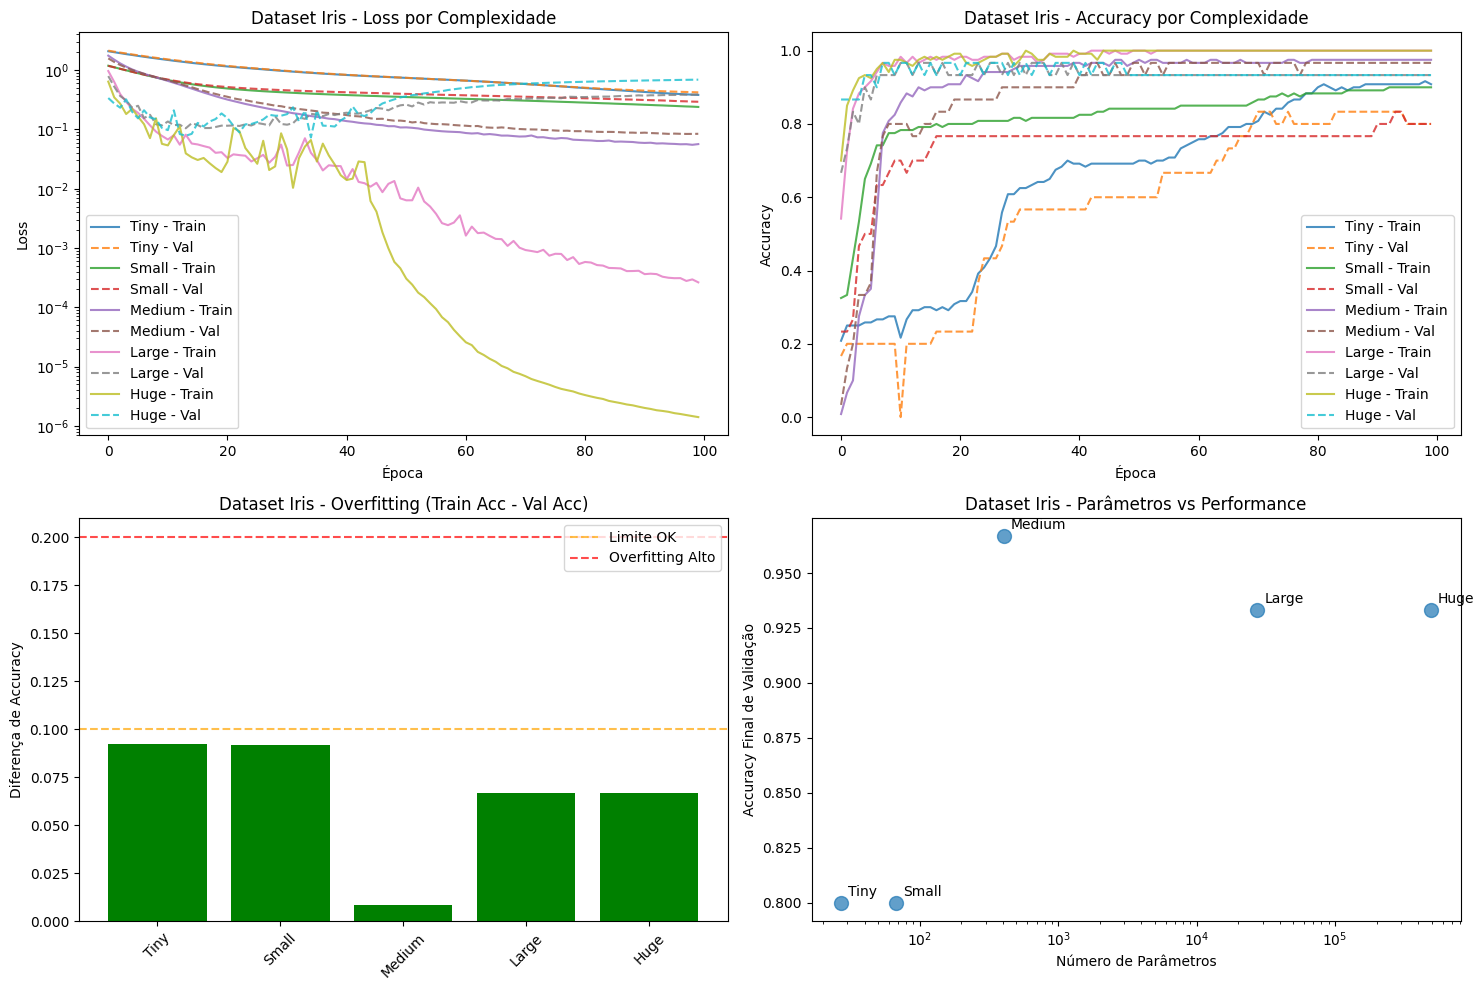

In [27]:
# Plotar resultados Iris
plt.figure(figsize=(15, 10))

# Loss
plt.subplot(2, 2, 1)
for name, history in iris_histories.items():
    plt.plot(history.history['loss'], label=f'{name} - Train', alpha=0.8)
    plt.plot(history.history['val_loss'], '--', label=f'{name} - Val', alpha=0.8)
plt.title('Dataset Iris - Loss por Complexidade')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.yscale('log')

# Accuracy
plt.subplot(2, 2, 2)
for name, history in iris_histories.items():
    plt.plot(history.history['accuracy'], label=f'{name} - Train', alpha=0.8)
    plt.plot(history.history['val_accuracy'], '--', label=f'{name} - Val', alpha=0.8)
plt.title('Dataset Iris - Accuracy por Complexidade')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Overfitting analysis
plt.subplot(2, 2, 3)
overfitting_scores = []
model_names = []
for name, history in iris_histories.items():
    # Pegando as últimas 10 épocas para calcular overfitting
    train_acc_final = np.mean(history.history['accuracy'][-10:])
    val_acc_final = np.mean(history.history['val_accuracy'][-10:])
    overfitting = train_acc_final - val_acc_final
    overfitting_scores.append(overfitting)
    model_names.append(name)

colors = ['green' if score < 0.1 else 'orange' if score < 0.2 else 'red' for score in overfitting_scores]
plt.bar(model_names, overfitting_scores, color=colors)
plt.title('Dataset Iris - Overfitting (Train Acc - Val Acc)')
plt.ylabel('Diferença de Accuracy')
plt.xticks(rotation=45)
plt.axhline(y=0.1, color='orange', linestyle='--', alpha=0.7, label='Limite OK')
plt.axhline(y=0.2, color='red', linestyle='--', alpha=0.7, label='Overfitting Alto')
plt.legend()

# Número de parâmetros vs performance
plt.subplot(2, 2, 4)
param_counts = []
final_val_acc = []
for name, model in iris_models:
    param_counts.append(model.count_params())
    final_val_acc.append(iris_histories[name].history['val_accuracy'][-1])

plt.scatter(param_counts, final_val_acc, s=100, alpha=0.7)
for i, name in enumerate([name for name, _ in iris_models]):
    plt.annotate(name, (param_counts[i], final_val_acc[i]), xytext=(5, 5), 
                textcoords='offset points')
plt.xlabel('Número de Parâmetros')
plt.ylabel('Accuracy Final de Validação')
plt.title('Dataset Iris - Parâmetros vs Performance')
plt.xscale('log')

plt.tight_layout()
plt.show()

Testando Early Stopping no modelo Iris...
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 11.
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 11.


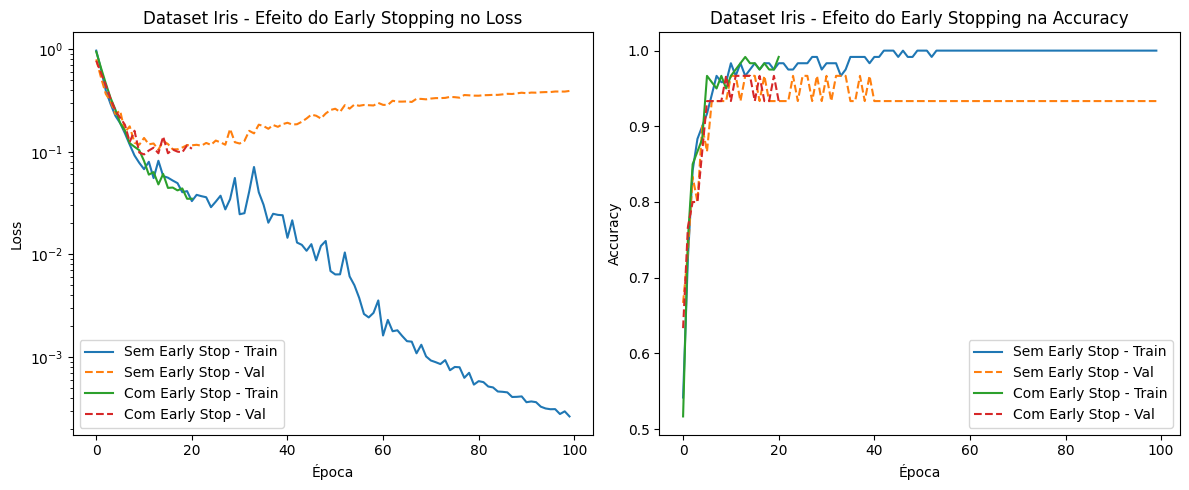

Épocas sem early stopping: 100
Épocas com early stopping: 21


In [28]:
# Early stopping para Iris
print("Testando Early Stopping no modelo Iris...")

# Modelo com early stopping
model_early_stop = create_iris_large_model()
model_early_stop.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Callback de early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Treinar com early stopping
history_early_stop = model_early_stop.fit(
    X_train_iris, y_train_iris,
    epochs=200,
    batch_size=8,
    validation_data=(X_test_iris, y_test_iris),
    callbacks=[early_stopping],
    verbose=0
)

# Comparar com modelo sem early stopping
iris_early_stop_comparison = {
    'Sem Early Stop': iris_histories['Large'],
    'Com Early Stop': history_early_stop
}

# Plotar comparação
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for name, history in iris_early_stop_comparison.items():
    plt.plot(history.history['loss'], label=f'{name} - Train')
    plt.plot(history.history['val_loss'], '--', label=f'{name} - Val')
plt.title('Dataset Iris - Efeito do Early Stopping no Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.yscale('log')

plt.subplot(1, 2, 2)
for name, history in iris_early_stop_comparison.items():
    plt.plot(history.history['accuracy'], label=f'{name} - Train')
    plt.plot(history.history['val_accuracy'], '--', label=f'{name} - Val')
plt.title('Dataset Iris - Efeito do Early Stopping na Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Épocas sem early stopping: {len(iris_early_stop_comparison['Sem Early Stop'].history['loss'])}")
print(f"Épocas com early stopping: {len(iris_early_stop_comparison['Com Early Stop'].history['loss'])}")

# Resumo e Conclusões

comparar os três datasets e resumir os principais insights sobre overfitting e underfitting.

In [33]:
# Análise comparativa dos três datasets
print("=== COMPARAÇÃO DOS TRÊS DATASETS ===\n")

# Características dos datasets
datasets_info = {
    'HIGGS': {
        'tamanho': 'Grande (10.000+ amostras)',
        'features': 28,
        'tipo': 'Física de partículas',
        'classes': 2,
        'complexidade': 'Alta'
    },
    'Fashion-MNIST': {
        'tamanho': 'Grande (60.000 amostras)',
        'features': 784,
        'tipo': 'Imagens',
        'classes': 10,
        'complexidade': 'Média-Alta'
    },
    'Iris': {
        'tamanho': 'Pequeno (150 amostras)',
        'features': 4,
        'tipo': 'Biológico',
        'classes': 3,
        'complexidade': 'Baixa'
    }
}

for dataset, info in datasets_info.items():
    print(f" {dataset}:")
    print(f"   • Tamanho: {info['tamanho']}")
    print(f"   • Features: {info['features']}")
    print(f"   • Tipo: {info['tipo']}")
    print(f"   • Classes: {info['classes']}")
    print(f"   • Complexidade: {info['complexidade']}")
    print()

print("=== PRINCIPAIS INSIGHTS ===\n")

insights = [
    "UNDERFITTING: Modelos muito simples têm performance ruim tanto em treino quanto em validação",
    "OVERFITTING: Modelos muito complexos memorizam os dados de treino mas generalizam mal",
    "EQUILÍBRIO: O modelo ideal balanceia complexidade suficiente sem overfitting excessivo",
    "REGULARIZAÇÃO: L2, Dropout e Early Stopping ajudam a controlar overfitting",
    "TAMANHO DOS DADOS: Datasets menores (como Iris) são mais propensos a overfitting",
    "MONITORAMENTO: A diferença entre loss de treino e validação indica overfitting"
]

for insight in insights:
    print(insight)


=== COMPARAÇÃO DOS TRÊS DATASETS ===

 HIGGS:
   • Tamanho: Grande (10.000+ amostras)
   • Features: 28
   • Tipo: Física de partículas
   • Classes: 2
   • Complexidade: Alta

 Fashion-MNIST:
   • Tamanho: Grande (60.000 amostras)
   • Features: 784
   • Tipo: Imagens
   • Classes: 10
   • Complexidade: Média-Alta

 Iris:
   • Tamanho: Pequeno (150 amostras)
   • Features: 4
   • Tipo: Biológico
   • Classes: 3
   • Complexidade: Baixa

=== PRINCIPAIS INSIGHTS ===

UNDERFITTING: Modelos muito simples têm performance ruim tanto em treino quanto em validação
OVERFITTING: Modelos muito complexos memorizam os dados de treino mas generalizam mal
EQUILÍBRIO: O modelo ideal balanceia complexidade suficiente sem overfitting excessivo
REGULARIZAÇÃO: L2, Dropout e Early Stopping ajudam a controlar overfitting
TAMANHO DOS DADOS: Datasets menores (como Iris) são mais propensos a overfitting
MONITORAMENTO: A diferença entre loss de treino e validação indica overfitting


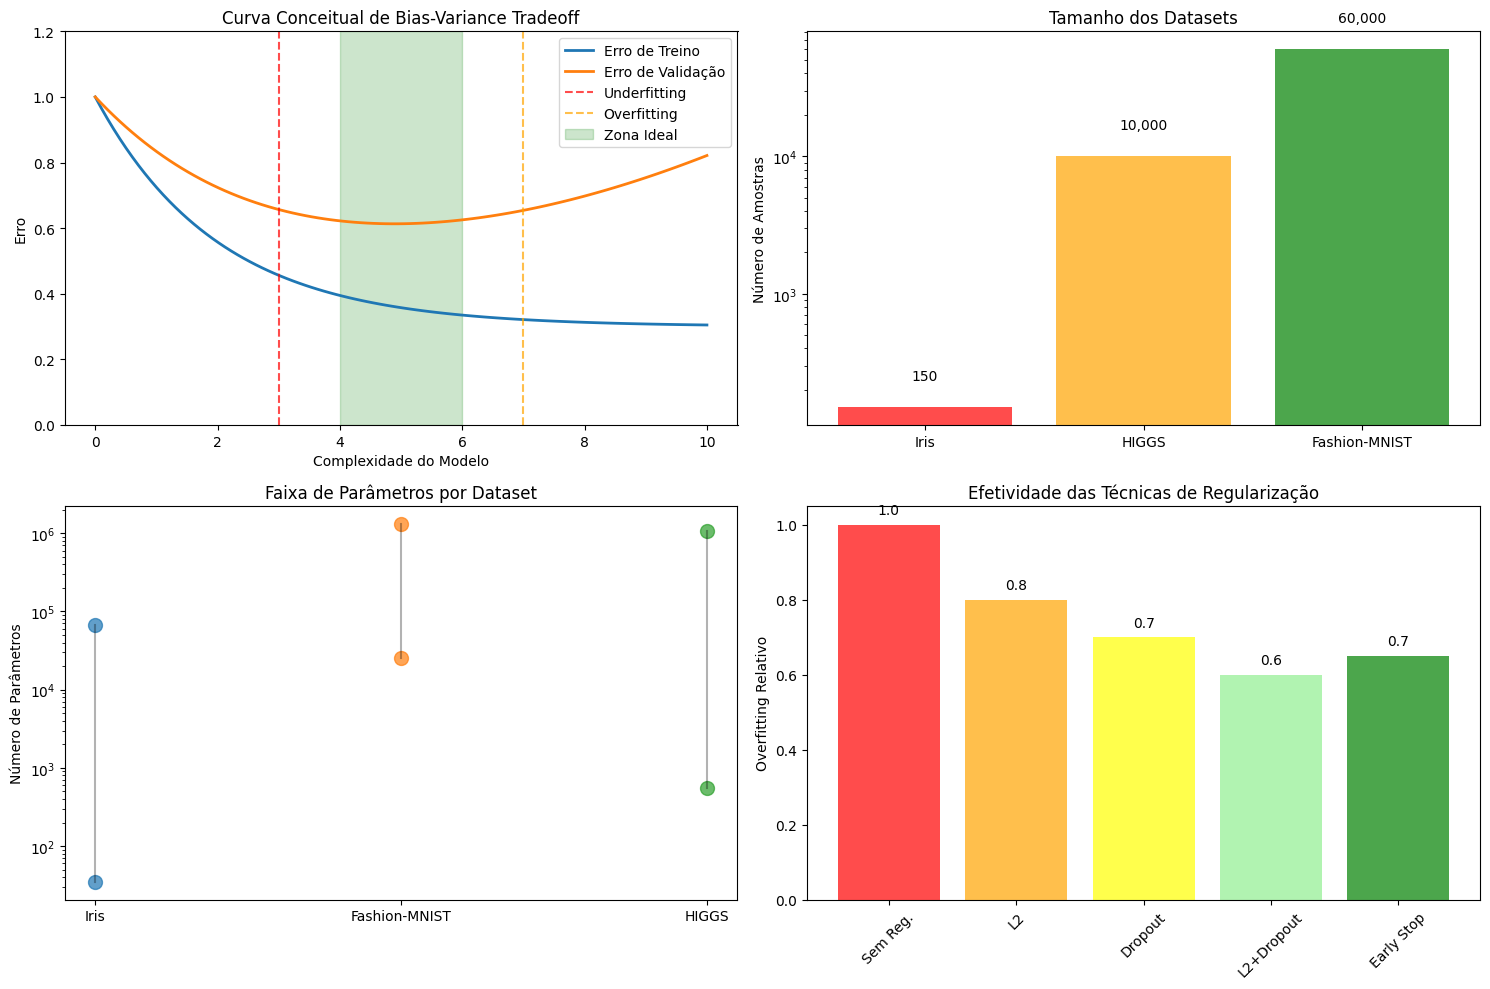

In [34]:
# Demonstração final: Visualização dos conceitos principais
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Curva conceitual de underfitting/overfitting
x = np.linspace(0, 10, 100)
train_error = 0.3 + 0.7 * np.exp(-x/2)
val_error = 0.4 + 0.6 * np.exp(-x/3) + 0.1 * (x/5)**2

axes[0, 0].plot(x, train_error, label='Erro de Treino', linewidth=2)
axes[0, 0].plot(x, val_error, label='Erro de Validação', linewidth=2)
axes[0, 0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Underfitting')
axes[0, 0].axvline(x=7, color='orange', linestyle='--', alpha=0.7, label='Overfitting')
axes[0, 0].fill_between([4, 6], 0, 1.2, alpha=0.2, color='green', label='Zona Ideal')
axes[0, 0].set_xlabel('Complexidade do Modelo')
axes[0, 0].set_ylabel('Erro')
axes[0, 0].set_title('Curva Conceitual de Bias-Variance Tradeoff')
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 1.2)

# 2. Comparação de datasets por tamanho
dataset_sizes = [150, 10000, 60000]
dataset_names = ['Iris', 'HIGGS', 'Fashion-MNIST']
colors = ['red', 'orange', 'green']

axes[0, 1].bar(dataset_names, dataset_sizes, color=colors, alpha=0.7)
axes[0, 1].set_ylabel('Número de Amostras')
axes[0, 1].set_title('Tamanho dos Datasets')
axes[0, 1].set_yscale('log')

# Adicionar rótulos
for i, (name, size) in enumerate(zip(dataset_names, dataset_sizes)):
    axes[0, 1].text(i, size * 1.5, f'{size:,}', ha='center', va='bottom')

# 3. Número de parâmetros vs datasets
param_ranges = {
    'Iris': [35, 67000],  # tiny to huge model
    'Fashion-MNIST': [25450, 1311754],  # tiny to large model
    'HIGGS': [545, 1050625]  # small to large model
}

positions = [0, 1, 2]
for i, (dataset, param_range) in enumerate(param_ranges.items()):
    axes[1, 0].scatter([i] * 2, param_range, s=100, alpha=0.7, label=dataset)
    axes[1, 0].plot([i, i], param_range, 'k-', alpha=0.3)

axes[1, 0].set_yscale('log')
axes[1, 0].set_xticks(positions)
axes[1, 0].set_xticklabels(param_ranges.keys())
axes[1, 0].set_ylabel('Número de Parâmetros')
axes[1, 0].set_title('Faixa de Parâmetros por Dataset')

# 4. Técnicas de regularização
techniques = ['Sem Reg.', 'L2', 'Dropout', 'L2+Dropout', 'Early Stop']
effectiveness = [1.0, 0.8, 0.7, 0.6, 0.65]  # Overfitting relativo

bars = axes[1, 1].bar(techniques, effectiveness, 
                     color=['red', 'orange', 'yellow', 'lightgreen', 'green'],
                     alpha=0.7)
axes[1, 1].set_ylabel('Overfitting Relativo')
axes[1, 1].set_title('Efetividade das Técnicas de Regularização')
axes[1, 1].tick_params(axis='x', rotation=45)

# Adicionar valores nas barras
for bar, value in zip(bars, effectiveness):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{value:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()